In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

processedData = "../data/processed/dataset_full_preprocessed.csv"
reducedDataDir = "../data/reduced"
outPath = os.path.join(reducedDataDir, "PCA_data.csv")

df = pd.read_csv(processedData)
df.shape

(13910, 130)

Number of components for 95% variance: 1


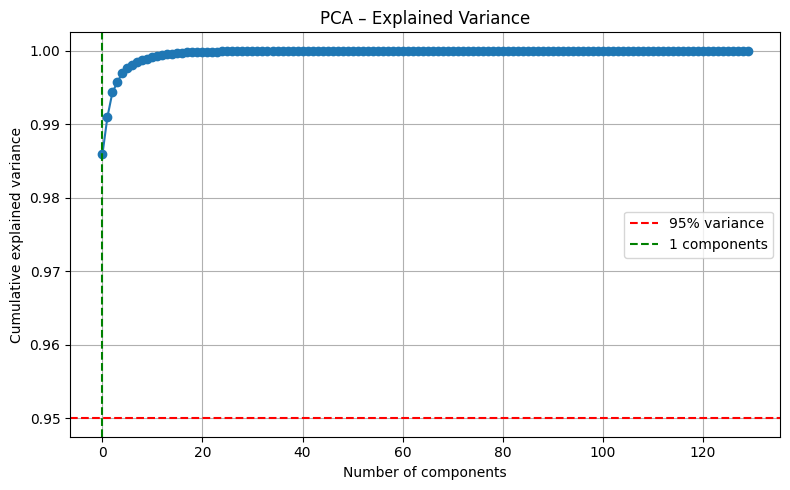

In [15]:
pca_full = PCA()
pca_full.fit(df)

explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

n_components_95 = np.argmax(explained_variance >= 0.95) + 1

print(f"Number of components for 95% variance: {n_components_95}")

plt.figure(figsize=(8, 5))
plt.plot(explained_variance, marker="o")
plt.axhline(y=0.95, color="r", linestyle="--", label="95% variance")
plt.axvline(x=n_components_95 - 1, color="g", linestyle="--",
            label=f"{n_components_95} components")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA – Explained Variance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
pca = PCA(n_components=n_components_95)
X_pca = pca.fit_transform(df)

pca_columns = [f"PC{i+1}" for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_columns)

print("PCA dataset shape:", df_pca.shape)

df_pca.to_csv(outPath, index=False)

PCA dataset shape: (13910, 1)


In [17]:
pca_fixed = PCA(n_components=2)
X_pca_2d = pca_fixed.fit_transform(df)
df_pca_2d = pd.DataFrame(X_pca_2d,columns=["PC1", "PC2"])
df_pca_2d.to_csv(os.path.join(reducedDataDir, "dataset_pca_2d.csv"),index=False)

df_pca_2d.shape

(13910, 2)